In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("../datasets/customer_segmentation/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]
X=X.values

In [8]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_scaled=scalar.fit_transform(X)


In [9]:
from sklearn.cluster import KMeans

In [10]:
wcss=[]
for i in range(1,12):
    k_means=KMeans(n_clusters=i,random_state=42)
    k_means.fit(X_scaled)
    wcss.append(k_means.inertia_)
print(wcss)

[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921344, 65.56840815571681, 60.13287487193422, 49.668244837367986, 37.319122878338824, 32.49508119910091, 30.05932269404221, 26.76120176636121]


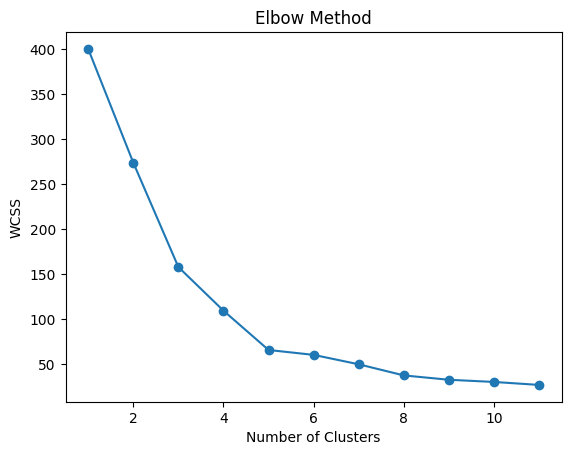

In [11]:
import matplotlib.pyplot as plt

plt.plot(range(1,12), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [12]:
model1=KMeans(n_clusters=5,random_state=42)
clusters=model1.fit_predict(X)
print(clusters)
df['cluster']=clusters

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [13]:
print(model1.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [14]:
centers = scalar.inverse_transform(
    model1.cluster_centers_
)

print(centers)

[[1509.26639924 1325.74167352]
 [2327.77917032 2165.73074176]
 [ 734.58822849 2094.51854127]
 [2371.30977839  491.0448656 ]
 [ 749.70700578  588.89661845]]


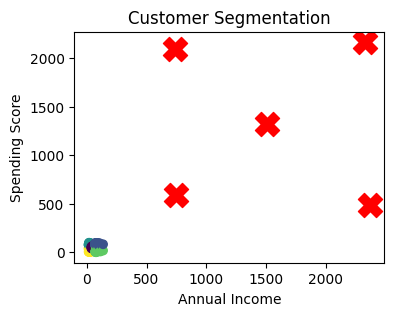

In [15]:
plt.figure(figsize=(4,3))

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap='viridis'
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    c='red',
    marker='X'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

In [16]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.histplot(df['Annual Income (k$)'])
# plt.show()

# sns.histplot(df['Spending Score (1-100)'])
# plt.show()

In [ ]:
# sns.scatterplot(
#     data=df,
#     x='Annual Income (k$)',
#     y='Spending Score (1-100)'
# )
# plt.show()

NameError: name 'sns' is not defined

In [18]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [38]:
df.groupby("cluster")["Spending Score (1-100)"].mean()

cluster
0    49.518519
1    82.128205
2    79.363636
3    17.114286
4    20.913043
Name: Spending Score (1-100), dtype: float64

In [ ]:
df.groupby('cluster')["Annual Income (k$)"].mean()

In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print(score)

0.5546571631111091


In [ ]:
df.head()

In [20]:
# from sklearn.preprocessing import LabelEncoder
# enc=LabelEncoder()
# enc_ender=enc.fit_transform(df['Gender'])
df['Gender']=df['Gender'].map({
    "Male":1,
    "Female":0
})

In [21]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


In [22]:
X1=df[['Gender','Age','Annual Income (k$)','Spending Score (1-100)']]

In [23]:
X1.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X1_scaled=scaler.fit_transform(X1)

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [27]:
from sklearn.cluster import KMeans
wcss1=[]
for i in range(1,20):
    k_means=KMeans(
        n_clusters=i, random_state=42
    )
    k_means.fit(X1_scaled)
    wcss1.append(k_means.inertia_)
print(wcss1)

[799.9999999999999, 597.9472937932279, 494.8037500130457, 395.3920903479797, 351.74320617119116, 277.38974019851906, 251.15484911190174, 211.98576294959307, 185.72807688711416, 152.02983429775688, 137.49737186521224, 130.34015200838118, 119.94131042961752, 115.66721679423239, 110.6593241095451, 98.99295590718833, 91.23987054978251, 87.17022581776574, 82.992025813518]


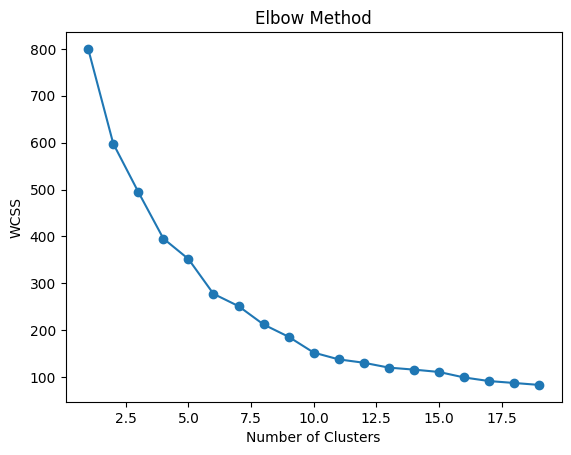

In [28]:
plt.plot(range(1,20), wcss1, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
df1=df.copy()
df1.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


In [ ]:
df1.drop(columns=['cluster'],inplace=False)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [34]:
model2=KMeans(n_clusters=6,random_state=42)
clusters=model1.fit_predict(X1_scaled)
print(clusters)

df1['cluster']=clusters

[2 2 4 4 4 4 4 4 0 4 0 4 0 4 0 2 4 2 0 4 2 2 0 2 0 2 0 2 4 4 0 4 0 2 0 4 0
 4 4 4 0 2 0 4 0 4 0 4 4 4 0 2 4 0 0 0 0 0 4 0 0 2 0 0 0 2 4 0 2 4 0 0 0 0
 0 2 3 2 4 0 0 2 0 3 4 0 0 4 4 0 0 2 0 3 4 2 3 4 0 2 4 3 0 2 0 4 0 0 0 0 0
 4 3 2 4 4 0 3 3 3 2 3 3 2 3 3 1 2 1 2 1 2 3 3 1 3 3 2 1 3 0 2 3 3 1 2 1 3
 3 2 1 2 3 3 3 3 1 3 1 3 3 3 1 3 1 3 1 3 3 2 1 2 1 2 3 3 1 2 1 2 3 3 1 3 3
 2 3 2 3 3 3 3 1 3 3 3 3 2 1 2]


In [37]:
df1.groupby('cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,,
0,65.333333,0.509804,56.470588,46.098039,39.313725
1,159.500000,1.000000,39.500000,85.150000,14.050000
2,100.809524,1.000000,28.690476,60.904762,70.238095
3,151.510204,0.000000,37.897959,82.122449,54.448980
4,50.526316,0.000000,27.315789,38.842105,56.210526


In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

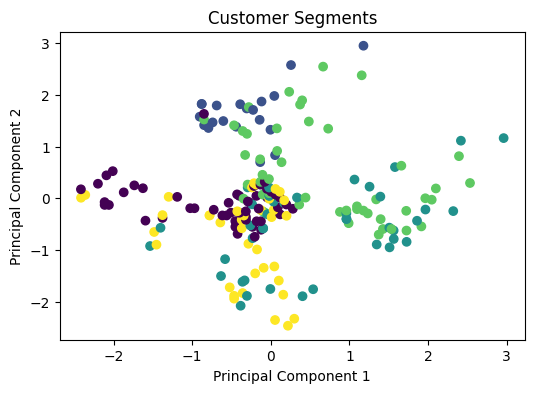

In [43]:
plt.figure(figsize=(6,4))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments")
plt.show()